# 🌩️ 01. Análisis Exploratorio de Datos: Estresores Climáticos y Fragilidad Eléctrica en la RM
## Proyecto: El Umbral del Apagón
> **Tesis Analítica:** El colapso del suministro eléctrico ante temporales no responde únicamente a eventos de fuerza mayor o intensidad meteorológica inédita, sino a una marcada asimetría de vulnerabilidad estructural preexistente entre las comunas de Santiago.

Este cuaderno documenta el análisis exploratorio de datos (EDA) sobre el dataset benchmark de los temporales de **Junio 2024** (río atmosférico con lluvia continua intensa) y **Agosto 2024** (viento destructivo con ráfagas superiores a 100-120 km/h) en las 52 comunas de la Región Metropolitana.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from gridbreak_cl.config import get_project_root
from gridbreak_cl.visualization.static_charts import set_portfolio_style

set_portfolio_style()
print("Entorno analítico configurado correctamente.")

Entorno analítico configurado correctamente.


## 1. Carga del Dataset Panel de Temporales 2024
Cargamos el panel consolidado de 52 comunas con 120 horas de observación.

In [2]:
root = get_project_root()
parquet_path = root / "data" / "processed" / "benchmark_temporales_2024.parquet"
df = pd.read_parquet(parquet_path)

print(f"Dimensiones del dataset: {df.shape[0]} filas (observaciones horarias-comuna) y {df.shape[1]} columnas.")
print(f"Eventos incluidos: {df['evento'].unique().tolist()}")
df.head(5)

Dimensiones del dataset: 2904 filas (observaciones horarias-comuna) y 20 columnas.
Eventos incluidos: ['Temporal_Junio_2024', 'Temporal_Agosto_2024']


,evento,timestamp,comuna_id,comuna_nombre,empresa,lat,lon,nse_score,ingreso_autonomo_promedio,pobreza_multidimensional,arbolado_m2_hab,red_aerea_km_ratio,es_rural,clientes_totales,clientes_sin_suministro,tasa_afectacion,es_corte_critico,precip_acumulada_mm,rafaga_max_kmh,rafaga_cuadratica
0,Temporal_Junio_2024,2024-06-20,13101,Santiago,ENEL,-33.4489,-70.6693,0.7,1250000,0.08,4.2,0.52,0,240000,705,0.002938,0,0.6,10.0,1.0
1,Temporal_Junio_2024,2024-06-20,13102,Cerrillos,ENEL,-33.5000,-70.7167,-0.4,680000,0.17,3.8,0.83,0,45000,449,0.009993,0,0.0,10.0,1.0
2,Temporal_Junio_2024,2024-06-20,13103,Cerro Navia,ENEL,-33.4242,-70.7381,-1.8,490000,0.28,2.1,0.91,0,48000,2015,0.041998,0,0.0,10.0,1.0
3,Temporal_Junio_2024,2024-06-20,13104,Conchalí,ENEL,-33.3833,-70.6833,-0.7,610000,0.21,3.1,0.86,0,52000,392,0.007545,0,0.1,10.0,1.0
4,Temporal_Junio_2024,2024-06-20,13105,El Bosque,ENEL,-33.5667,-70.6833,-1.1,560000,0.23,2.6,0.91,0,62000,1286,0.020755,0,0.7,10.0,1.0


## 2. Resumen Estadístico de las Variables Principales
Examinamos la distribución de precipitaciones, ráfagas, porcentaje de cableado aéreo y clientes afectados.

In [3]:
metric_cols = [
    "precip_acumulada_mm",
    "rafaga_max_kmh",
    "red_aerea_km_ratio",
    "arbolado_m2_hab",
    "clientes_totales",
    "clientes_sin_suministro",
    "tasa_afectacion",
]
stats = df[metric_cols].describe().T[["mean", "std", "min", "50%", "max"]]
stats.columns = ["Media", "Desv. Estándar", "Mínimo", "Mediana", "Máximo"]
stats.round(2)

,Media,Desv. Estándar,Mínimo,Mediana,Máximo
precip_acumulada_mm,26.67,20.22,0.00,23.10,71.10
rafaga_max_kmh,43.80,33.63,10.00,35.50,146.60
red_aerea_km_ratio,0.80,0.18,0.28,0.86,0.98
arbolado_m2_hab,5.14,3.50,1.80,3.85,16.50
clientes_totales,65965.91,50018.66,8500.00,47500.00,240000.00
clientes_sin_suministro,6040.13,7685.40,12.00,3986.50,58706.00
tasa_afectacion,0.10,0.08,0.00,0.09,0.28


## 3. Matriz de Correlaciones: Estresores Climáticos vs. Falla de Red
Analizamos la correlación lineal y de rango entre las variables físicas y la tasa de corte eléctrico.

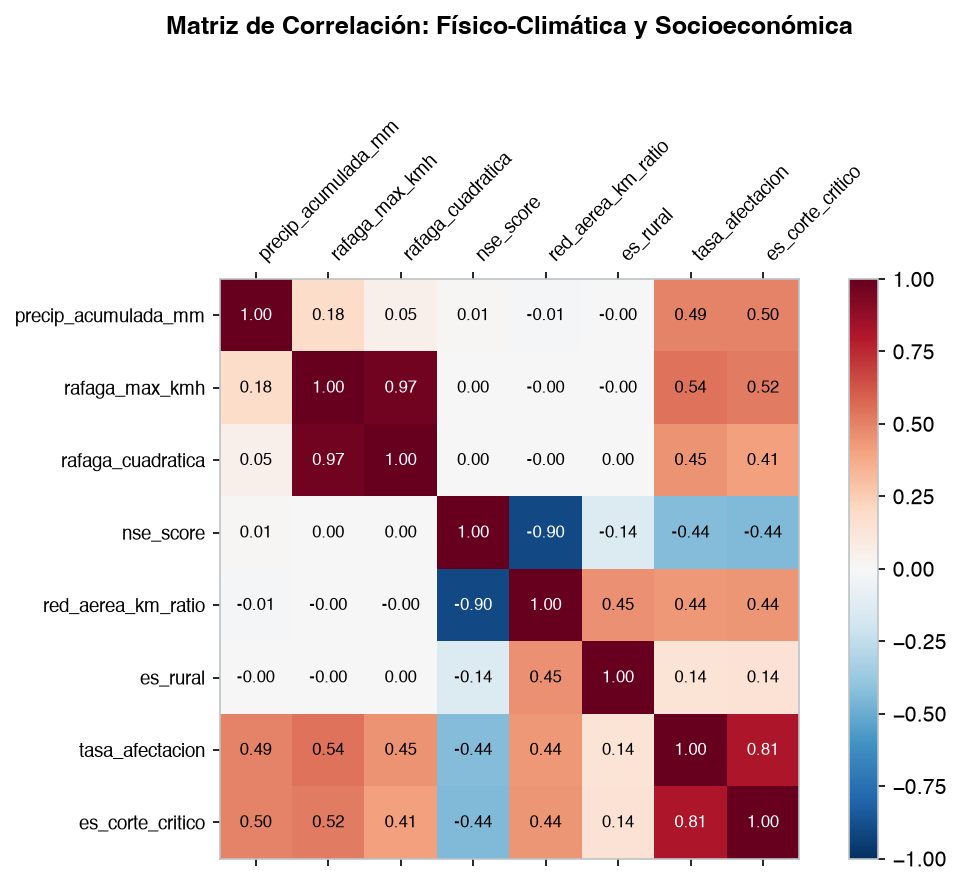

In [4]:
corr_cols = [
    "precip_acumulada_mm",
    "rafaga_max_kmh",
    "rafaga_cuadratica",
    "nse_score",
    "red_aerea_km_ratio",
    "es_rural",
    "tasa_afectacion",
    "es_corte_critico",
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)
cax = ax.matshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
fig.colorbar(cax)

ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="left", fontsize=9)
ax.set_yticklabels(corr_cols, fontsize=9)
ax.set_title("Matriz de Correlación: Físico-Climática y Socioeconómica", pad=40, fontweight="bold")

for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="black" if abs(val) < 0.6 else "white", fontsize=8)

plt.tight_layout()
plt.show()

## 4. Brecha Socioeconómica: Afectación por Tercil de NSE
Dividimos las comunas en terciles según su `nse_score`:
- **Tercil 1 (Vulnerable):** Menores ingresos, mayor pobreza multidimensional y alta proporción de red aérea.
- **Tercil 2 (Medio):** Comunas mesocráticas consolidadas.
- **Tercil 3 (Alto):** Mayores ingresos, redes más soterradas y mayor inversión en mantención.

In [5]:
df['tercil_nse'] = pd.qcut(df['nse_score'], q=3, labels=['Vulnerable', 'Medio', 'Alto'])

tercil_summary = df.groupby('tercil_nse', observed=False).agg(
    comunas=('comuna_nombre', 'nunique'),
    ingreso_medio=('ingreso_autonomo_promedio', 'mean'),
    red_aerea_media=('red_aerea_km_ratio', 'mean'),
    tasa_corte_media=('tasa_afectacion', 'mean'),
    tasa_corte_max=('tasa_afectacion', 'max'),
    prob_corte_critico=('es_corte_critico', 'mean'),
).round(3)

tercil_summary

,comunas,ingreso_medio,red_aerea_media,tasa_corte_media,tasa_corte_max,prob_corte_critico
tercil_nse,,,,,,
Vulnerable,15,549333.333,0.913,0.128,0.278,0.768
Medio,15,676666.667,0.886,0.112,0.276,0.700
Alto,14,1415000.000,0.599,0.057,0.271,0.360


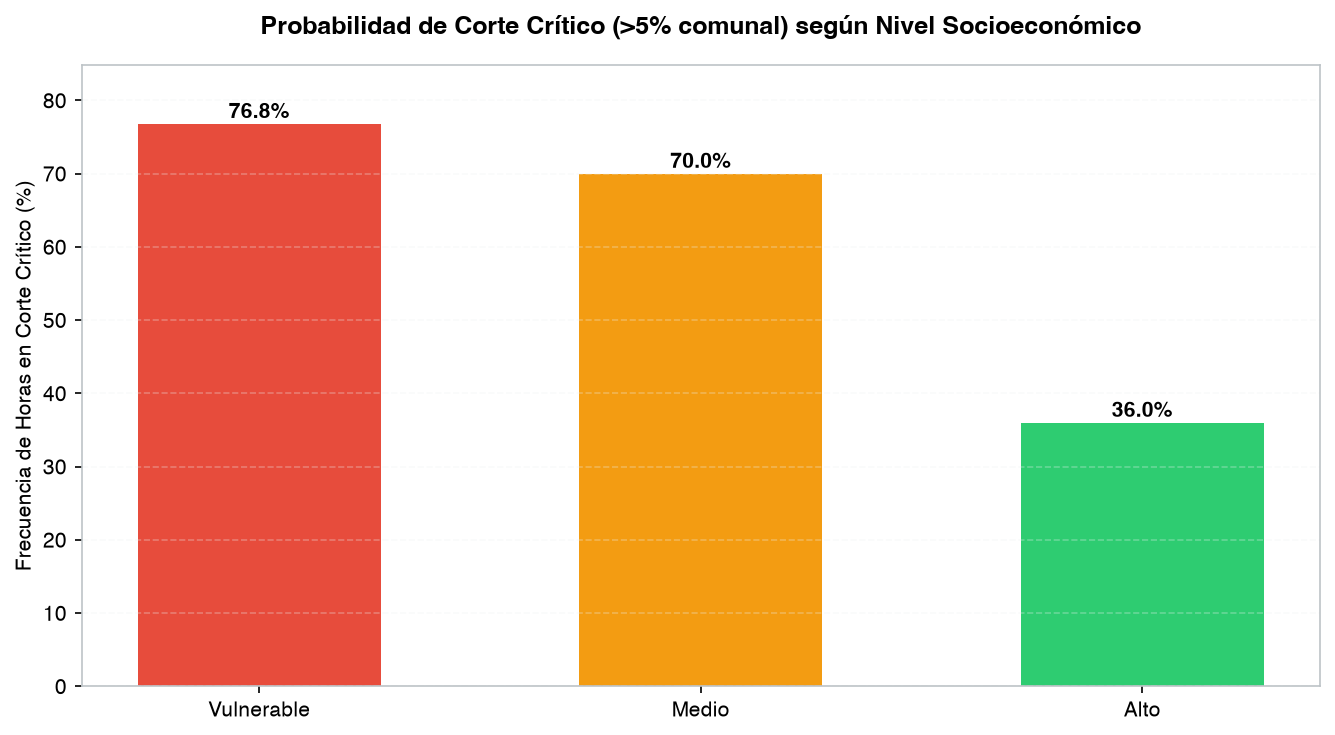

In [6]:
fig, ax = plt.subplots(figsize=(9, 5), dpi=150)

terciles = ['Vulnerable', 'Medio', 'Alto']
prob_crit = [tercil_summary.loc[t, 'prob_corte_critico'] * 100 for t in terciles]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

bars = ax.bar(terciles, prob_crit, color=colors, width=0.55)
for bar, val in zip(bars, prob_crit, strict=False):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8, f"{val:.1f}%", ha='center', fontweight='bold', fontsize=10)

ax.set_title("Probabilidad de Corte Crítico (>5% comunal) según Nivel Socioeconómico", fontweight="bold", pad=15)
ax.set_ylabel("Frecuencia de Horas en Corte Crítico (%)")
ax.set_ylim(0, max(prob_crit) + 8)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Comparativa por Distribuidora: Enel vs. CGE
Examinamos el comportamiento de las concesiones de Enel Distribución (principalmente urbanas RM) versus CGE (periféricas y rurales).

In [7]:
empresa_summary = df.groupby('empresa').agg(
    comunas=('comuna_nombre', 'nunique'),
    clientes_totales=('clientes_totales', 'first'),
    red_aerea_media=('red_aerea_km_ratio', 'mean'),
    tasa_corte_media=('tasa_afectacion', 'mean'),
    pct_horas_criticas=('es_corte_critico', 'mean'),
).round(3)

empresa_summary

,comunas,clientes_totales,red_aerea_media,tasa_corte_media,pct_horas_criticas
empresa,,,,,
CGE,9,210000,0.936,0.123,0.742
ENEL,35,240000,0.770,0.094,0.582


## 6. Conclusiones del Análisis Exploratorio
1. **Asimetría Estructural Evidente:** Las comunas del tercil vulnerable sufren una probabilidad de corte crítico significativamente superior frente al tercil acomodado.
2. **Rol de la Red Aérea:** La correlación positiva entre exposición aérea (`red_aerea_km_ratio`) y tasa de falla respalda la hipótesis de que la falta de soterramiento amplifica la fragilidad.
3. **No Linealidad del Viento:** El impacto de las ráfagas exhibe una relación cuadrática acentuada, coherente con las leyes de presión aerodinámica ($P \propto v^2$).
4. **Siguiente Paso:** Ajustar formalmente el modelo GLM bivariado con términos de interacción y el análisis de supervivencia en el Cuaderno 02.